# Notebook 01.4 — Visualização cartográfica e análise exploratória

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — Pipeline AE2SFCA  
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI  
**Autor:** Felipe Ramos Dantas  
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs  
**Última atualização:** 2026-06-10

## Objetivo

Consolidar os resultados das aquisições dos notebooks **01.1 (IBGE)**, **01.2 (Overture)** e **01.3 (UBS / CNES)** em duas frentes:

1. **Caracterização cartográfica** — gerar as figuras-síntese do Capítulo 1 da dissertação (área de estudo, demanda, oferta, infraestrutura).
2. **Análise exploratória inicial** — tabelas-síntese dos quantitativos espaciais e socioeconômicos, servindo de base para os capítulos seguintes.

> Este notebook **não altera nenhum dado** — apenas lê e plota.

## Entrada

| Arquivo | Origem |
|---|---|
| `dados/externos/ibge/teresina_municipio.parquet` | NB 01.1 |
| `dados/externos/ibge/teresina_zonaUrbana_buffer5kClip_utm.parquet` | NB 01.1 |
| `dados/externos/ibge/teresina_zonaUrbana_utm.parquet` | NB 01.1 |
| `dados/intermediarios/01_malha/teresina_setoresCensitarios_DadosCompletos.parquet` | NB 01.1 |
| `dados/externos/overture/zonaUrbana_5km_segmentos.parquet` (+conectores, buildings) | NB 01.2 |
| `dados/intermediarios/01_ubs/teresina_ubs_utm.parquet` | NB 01.3 |

## Saídas

| Figura | Arquivo |
|---|---|
| 1.1 — Delimitação da área de estudo | `outputs/figuras/1.1_figura_area_estudo.png` |
| 1.2 — Renda mediana por setor censitário | `outputs/figuras/1.2_figura_demanda_renda.png` |
| 1.3 — Distribuição das UBS na zona urbana | `outputs/figuras/1.3_figura_oferta_ubs.png` |
| 1.4 — Detalhe da topologia da infraestrutura | `outputs/figuras/1.4_figura_infraestrutura_zoom.png` |

## Pré-requisitos

- NBs **01.1, 01.2 e 01.3** executados.
- Nenhuma alteração nos dados é feita aqui — execução repetível à vontade.

---

In [6]:
# ── 1. Imports e configuração ────────────────────────────────────────────────
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

# Caminhos centralizados (ver src/mapeprof/config.py)
from mapeprof.config import (
    EXT_IBGE,        # recortes IBGE (NB 01.1)
    EXT_OVERTURE,    # malha viária e buildings (NB 01.2)
    INT_MALHA,       # setores censitários enriquecidos (NB 01.1)
    EXT_PMT,         # UBS de Teresina (NB 01.3)
    FIGURAS,         # outputs/figuras
    CRS_METRICO,
)

# Estilo e helpers cartográficos
from mapeprof.viz import aplicar_estilo, barra_escala, seta_norte, moldura_mapa

aplicar_estilo()
print("Setup concluído.")

Setup concluído.


## 2. Síntese da área de estudo

Antes das figuras, um quadro-resumo com os totais de cada camada — para dimensionar o problema e dar contexto ao leitor da dissertação.

In [7]:
# ── Quadro-síntese da área de estudo ─────────────────────────────────────────
# Carrega só o que é leve (parquet); o GeoJSON pesado de buildings só é lido sob demanda.
gdf_teresina_mun = gpd.read_parquet(EXT_IBGE / "teresina_municipio.parquet")
gdf_zu           = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet")
gdf_buffer       = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_buffer5kClip_utm.parquet")
gdf_setores      = gpd.read_parquet(INT_MALHA / "teresina_setoresCensitarios_DadosCompletos.parquet")
gdf_segmentos    = gpd.read_parquet(EXT_OVERTURE / "zonaUrbana_5km_segmentos.parquet")
gdf_conectores   = gpd.read_parquet(EXT_OVERTURE / "zonaUrbana_5km_conectores.parquet")
gdf_ubs          = gpd.read_file(EXT_PMT / "teresina_ubs.geojson").to_crs(CRS_METRICO)

# Métricas espaciais em km² e km (sempre em CRS métrico)
area_municipio_km2 = gdf_teresina_mun.area.sum() / 1e6
area_zu_km2        = gdf_zu.area.sum() / 1e6
area_buffer_km2    = gdf_buffer.area.sum() / 1e6
extensao_viaria_km = gdf_segmentos.length.sum() / 1e3

sintese = pd.DataFrame({
    "Componente": [
        "Município de Teresina",
        "Zona Urbana consolidada",
        "Área de estudo (ZU + buffer 5 km)",
        "Setores censitários urbanos",
        "Segmentos viários (Overture)",
        "Conectores viários (Overture)",
        "Extensão viária total",
        "Unidades Básicas de Saúde (UBS)",
    ],
    "Quantidade / Medida": [
        f"{area_municipio_km2:,.1f} km²",
        f"{area_zu_km2:,.1f} km²",
        f"{area_buffer_km2:,.1f} km²",
        f"{len(gdf_setores):,} setores",
        f"{len(gdf_segmentos):,} arestas",
        f"{len(gdf_conectores):,} nós",
        f"{extensao_viaria_km:,.1f} km",
        f"{len(gdf_ubs):,} estabelecimentos",
    ],
})

print("Tabela 1.1 — Síntese da área de estudo (Teresina, PI)")
print(sintese.to_string(index=False))

Tabela 1.1 — Síntese da área de estudo (Teresina, PI)
                       Componente Quantidade / Medida
            Município de Teresina         1,388.5 km²
          Zona Urbana consolidada           250.0 km²
Área de estudo (ZU + buffer 5 km)           532.4 km²
      Setores censitários urbanos       1,403 setores
     Segmentos viários (Overture)      46,477 arestas
    Conectores viários (Overture)          34,742 nós
            Extensão viária total          4,745.9 km
  Unidades Básicas de Saúde (UBS) 75 estabelecimentos


## 5. Figura 1.3 — Distribuição espacial das UBS

Localização das Unidades Básicas de Saúde dentro da Zona Urbana de Teresina. Esta figura introduz a **camada de oferta** do modelo AE2SFCA: nos NBs 04 e 05, cada UBS será o ponto-origem das isócronas de tempo de deslocamento.

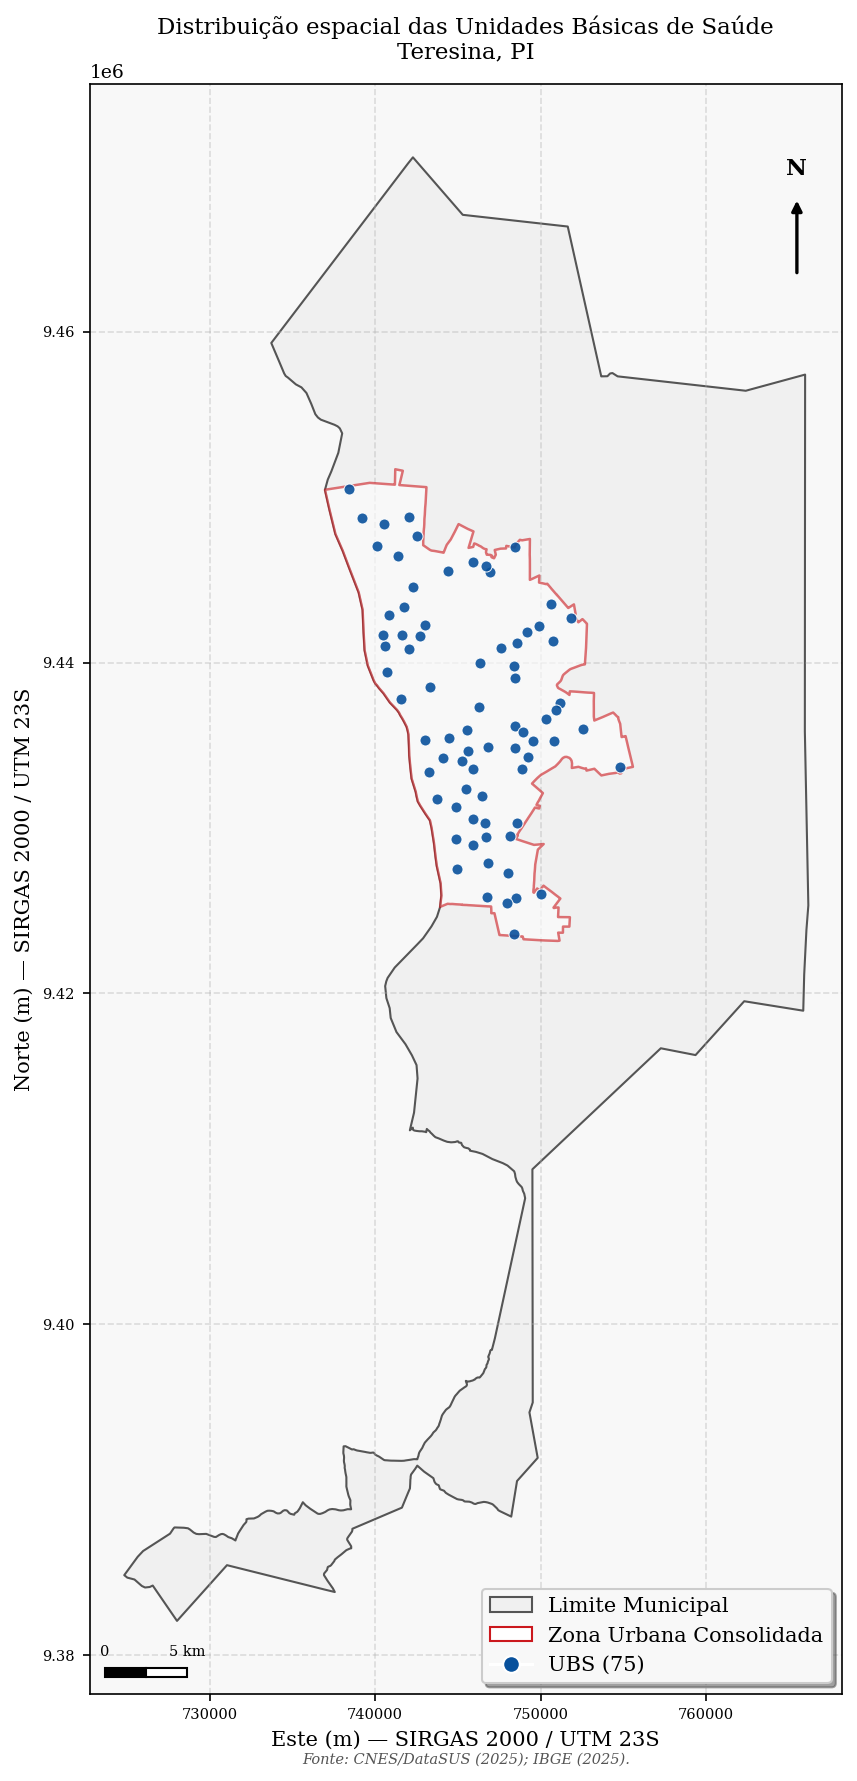

In [8]:
# ── Figura 1.3 — Distribuição espacial das UBS ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))

# Fundo: contorno do município + zona urbana
gdf_teresina_mun.plot(ax=ax, color='#f0f0f0', edgecolor='#555555', linewidth=1, zorder=1)
gdf_zu.plot(ax=ax, color='#ffffff', edgecolor='#cb181d', linewidth=1.2, alpha=0.6, zorder=2)

# Pontos das UBS
gdf_ubs.plot(ax=ax, color='#08519c', markersize=28, edgecolor='white',
             linewidth=0.5, alpha=0.9, zorder=3)

# Legenda
ax.legend(handles=[
    mpatches.Patch(color='#f0f0f0', ec='#555555', label='Limite Municipal'),
    mpatches.Patch(color='#ffffff', ec='#cb181d', label='Zona Urbana Consolidada'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#08519c',
               markersize=8, label=f'UBS ({len(gdf_ubs)})'),
], loc='lower right', fontsize=10, frameon=True, shadow=True)

moldura_mapa(ax,
             'Distribuição espacial das Unidades Básicas de Saúde\nTeresina, PI',
             'CNES/DataSUS (2025); IBGE (2025).')
barra_escala(ax, comprimento_m=5000, rotulo='5 km')
seta_norte(ax)

plt.tight_layout()
plt.savefig(FIGURAS / "1.3_figura_oferta_ubs.png", bbox_inches='tight')
plt.show()

In [11]:
url_pi = "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2025/UFs/PI/PI_Municipios_2025.zip"
gdf_pi_uf = gpd.read_file(f"zip+{url_pi}").dissolve()[['geometry']].to_crs(31983)

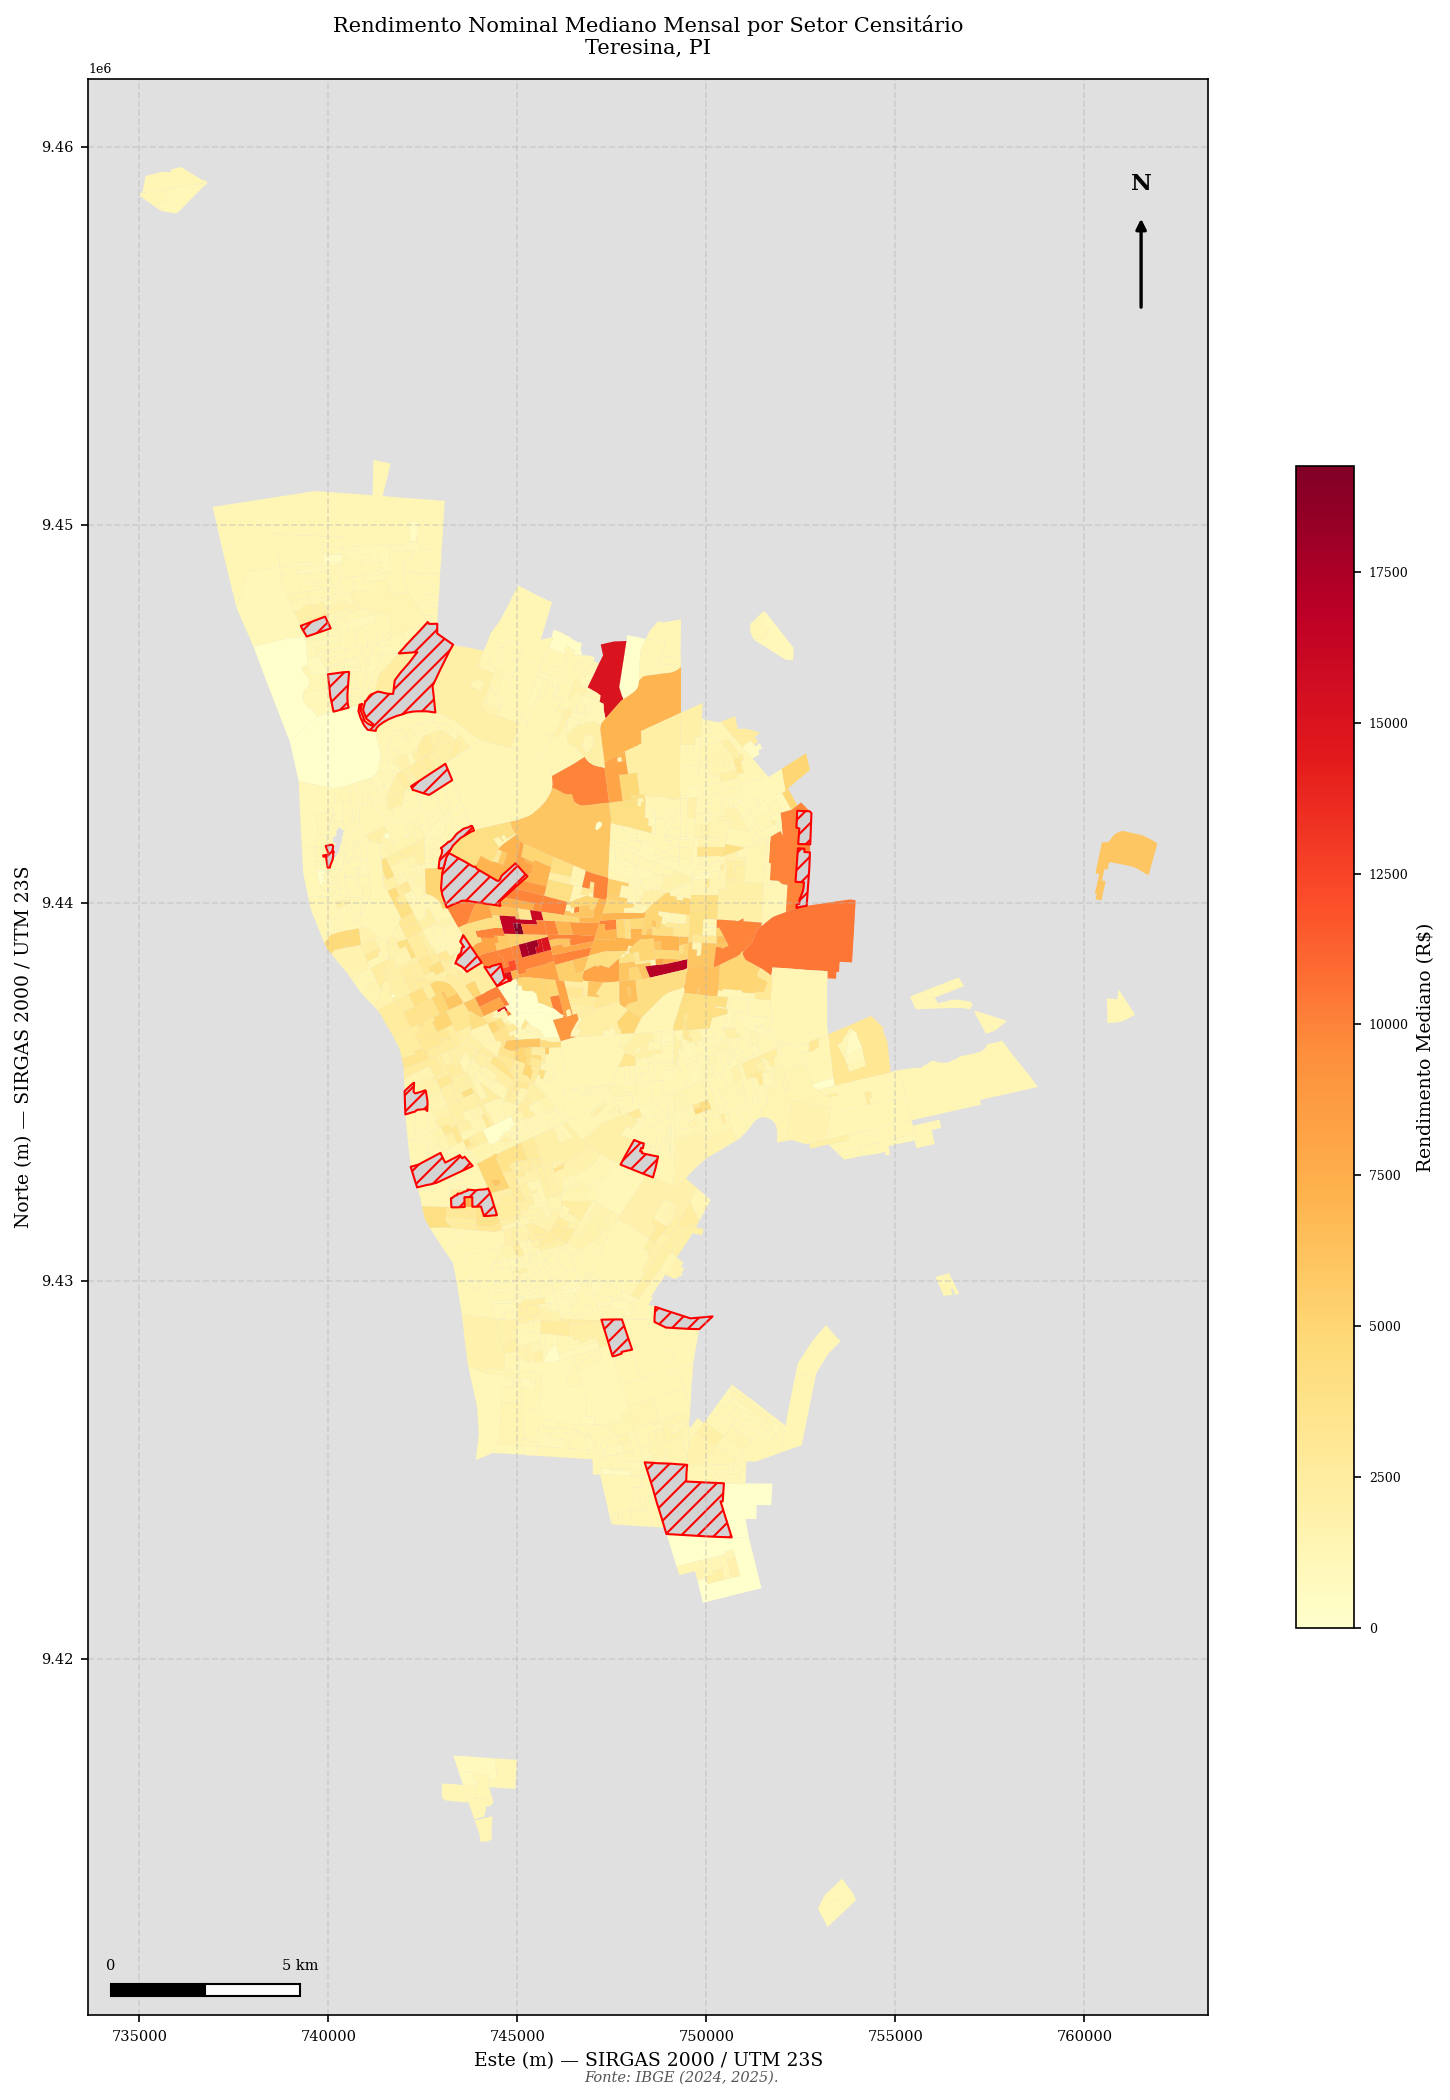

In [26]:
# 1. Carregando a malha de setores censitários enriquecida
gdf_setores = gpd.read_parquet(DIR_PROC / "teresina_setoresCensitarios_DadosCompletos.parquet")

# 2. Configurando a figura
fig, ax = plt.subplots(figsize=(12, 14))
ax.set_title("Rendimento Nominal Mediano Mensal por Setor Censitário", fontsize=14, pad=15)
ax.set_facecolor('#e0e0e0') # Fundo levemente cinza para destacar vazios urbanos

# 3. Plotagem do Mapa Coroplético (Mapa de Calor)
# O cmap 'YlOrRd' (Yellow-Orange-Red) é excelente para representar gradação de valores
gdf_setores.plot(
    column='V06006_renda', 
    ax=ax, 
    cmap='YlOrRd', 
    edgecolor='none', # Remove a borda dos setores para não poluir
    legend=True,
    legend_kwds={
        'label': "Rendimento Mediano (R$)",
        'orientation': "vertical",
        'shrink': 0.6 # Tamanho da barra lateral
    },
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "red",
        "hatch": "///",
        "label": "Dados não disponíveis/Censurados"
    }
)

# 5. Ocultar os eixos de coordenadas (limpeza visual)
moldura_mapa(ax, 'Rendimento Nominal Mediano Mensal por Setor Censitário\nTeresina, PI', 'IBGE (2024, 2025).')
barra_escala(ax, comprimento_m=5000, rotulo='5 km')
seta_norte(ax)

plt.tight_layout()
plt.savefig("../outputs/figuras/1.2_figura_demanda_renda.png", bbox_inches='tight')
plt.show()

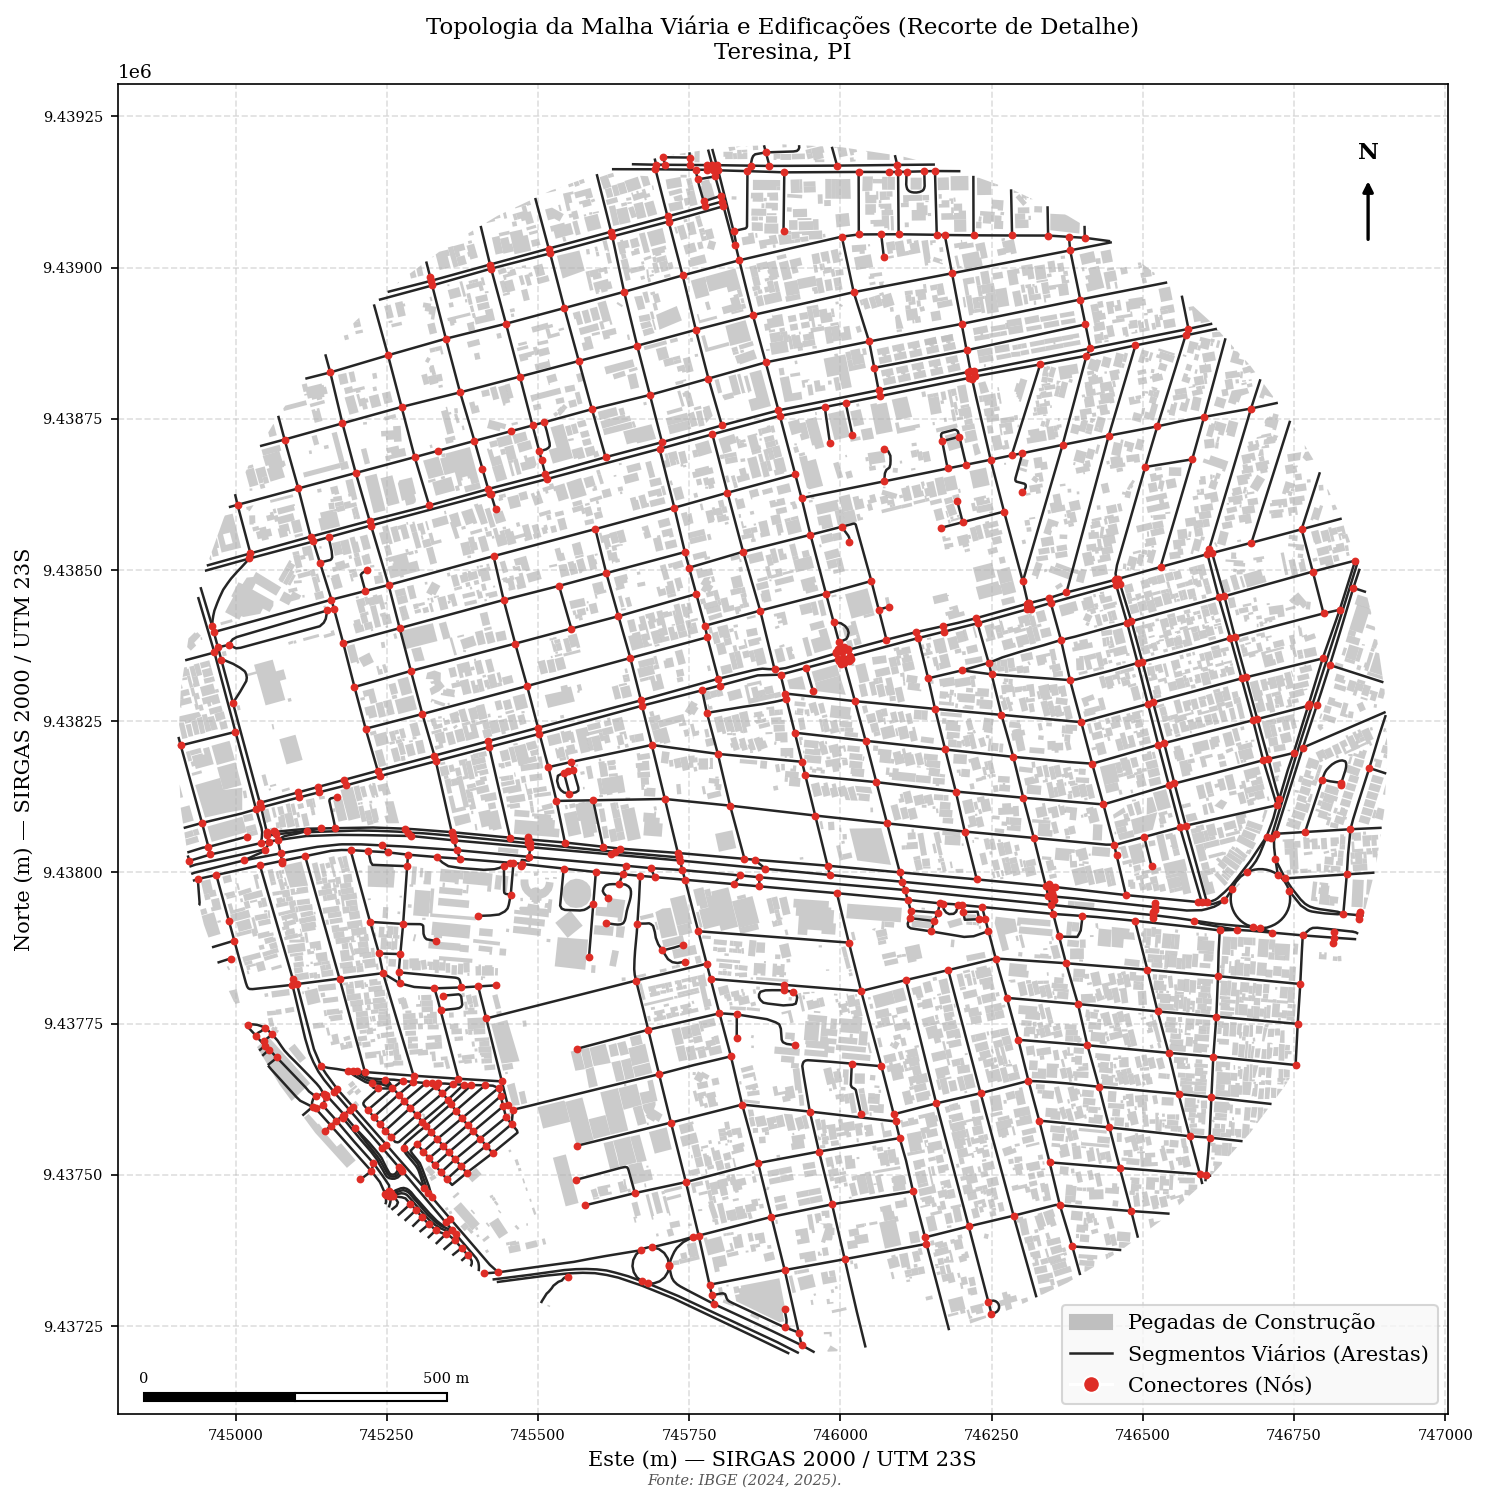

In [11]:
# 1. Carregando as camadas de infraestrutura
gdf_segmentos  = gpd.read_parquet(EXT_OVERTURE / "zonaUrbana_5km_segmentos.parquet")
gdf_conectores = gpd.read_parquet(EXT_OVERTURE / "zonaUrbana_5km_conectores.parquet")
gdf_buildings = gpd.read_file(EXT_OVERTURE  / "zonaUrbana_building_utm.geojson")

# 2. Criando um Bounding Box para o Zoom (raio de 1.5 km no centroide da zona urbana)
# Carrega a zona urbana para achar o "meio" dela
gdf_zu = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet")
ponto_central = gdf_zu.geometry.centroid.iloc[0]
area_zoom = ponto_central.buffer(1000) # Buffer de 1.5 km

# 3. Recortando (Clip) os dados pesados apenas para a área de zoom
gdf_seg_zoom = gpd.clip(gdf_segmentos, area_zoom)
gdf_con_zoom = gpd.clip(gdf_conectores, area_zoom)
gdf_bld_zoom = gpd.clip(gdf_buildings, area_zoom)

# 4. Configurando a figura
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("Topologia da Malha Viária e Edificações (Recorte de Detalhe)", fontsize=12, pad=15)
ax.set_facecolor('#ffffff')

# 5. Plotagem das geometrias micrométricas
# Pegadas de construção como blocos cinzas
gdf_bld_zoom.plot(ax=ax, color='#bfbfbf', edgecolor='none', alpha=0.8, zorder=1)

# Segmentos da rua como linhas pretas
gdf_seg_zoom.plot(ax=ax, color='#252525', linewidth=1.2, zorder=2)

# Conectores (nós de interseção) como pontos vermelhos
gdf_con_zoom.plot(ax=ax, color='#de2d26', markersize=7.5, zorder=3)

# 6. Criação da Legenda Manual
leg_bld = mpatches.Patch(color='#bfbfbf', label='Pegadas de Construção')
leg_seg = plt.Line2D([0], [0], color='#252525', lw=1.2, label='Segmentos Viários (Arestas)')
leg_con = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#de2d26', markersize=8, label='Conectores (Nós)')

ax.legend(handles=[leg_bld, leg_seg, leg_con], loc='lower right', fontsize=10, frameon=True)

# 5. Ocultar os eixos de coordenadas (limpeza visual)
moldura_mapa(ax, 'Topologia da Malha Viária e Edificações (Recorte de Detalhe)\nTeresina, PI', 'IBGE (2024, 2025).')
barra_escala(ax, comprimento_m=500, rotulo='500 m')
seta_norte(ax)

plt.tight_layout()
plt.savefig(FIGURAS / "1.4_figura_infraestrutura_zoom.png", bbox_inches='tight')
plt.show()